1) markvlovitz
2) black letterman
3) risk parity (erc, naive, hierachy)
Add naive + erc

In [1]:
from helper import get_matrices, get_ticker_expected, plot_efficient_frontier, get_market_caps, get_black_litterman, get_full_portfolio_df
from helper import run_hrp_optimization, run_cvar_optimization, get_returns, run_nrp_optimization, run_erp_optimization
from finbert import ai_bl_params
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline


/Users/sjegoh/Documents/GitHub/NUSSIF/Portfolio-Optimizer/venv_optimizer/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
2026-03-09 19:14:27.898 No runtime found, using MemoryCacheStorageManager


In [35]:
basket = [
    "XOM",   # Energy: The most valuable company in the world in 2005
    "GE",    # Industrials: The gold standard of diversified conglomerates
    "MSFT",  # Tech: Dominant but viewed as a "stagnant" value play in 2005
    "C",     # Financials: Citigroup was a massive institutional staple
    "WFC",   # Financials: Wells Fargo was the "safe" regional banking play
    "PFE",   # Health Care: Pfizer was the dominant pharma name
    "KO",    # Staples: Coca-Cola, a classic "Sleep-at-Night" defensive
    "INTC",  # Tech: Intel was the undisputed king of semiconductors
    "WMT",   # Discretionary: Walmart was the retail world-beater
    "AIG",   # Financials: Considered "Too Big to Fail" before 2008
    "IBM",   # Tech: The bedrock of enterprise IT
    "TLT"    # Fixed Income: 20-Year Treasuries for diversification
]
start_date = "2024-01-01"


In [36]:
cv, _ = get_matrices(basket, start_date = start_date)


In [37]:
stats = get_ticker_expected(basket, start_date = start_date)
stats


,Expected Return,Volatility
XOM,0.177724,0.223152
GE,0.537226,0.309301
MSFT,0.045630,0.236937
C,0.322128,0.301091
WFC,0.216351,0.291394
PFE,-0.047715,0.246536
KO,0.121293,0.156549
INTC,-0.021949,0.605997
WMT,0.392725,0.221096
AIG,0.055403,0.233240


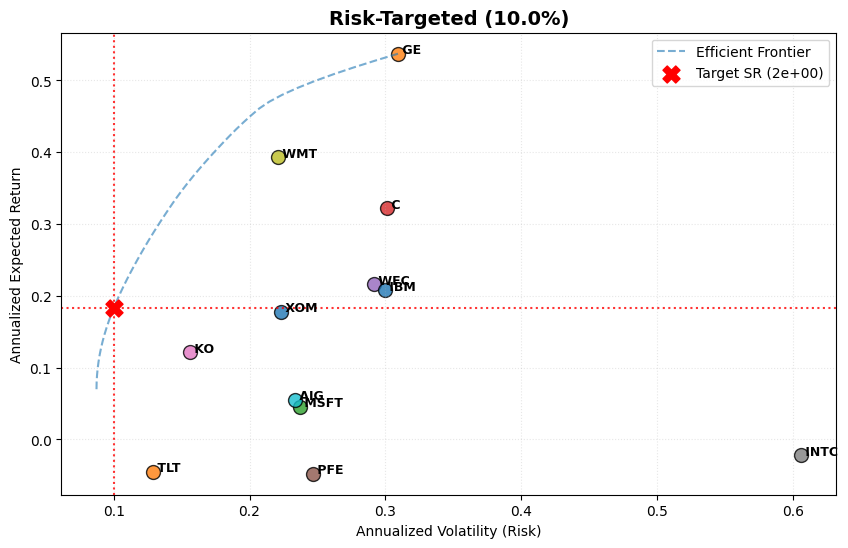

In [38]:
fig, weights = plot_efficient_frontier(stats, cv, basket, target_vol = 0.1)
plt.show()


In [6]:
weights


XOM     1.316714e-01
GE      1.128091e-01
MSFT    5.505107e-02
C       1.644978e-17
WFC     3.049646e-02
PFE     1.242861e-17
KO      2.181190e-01
INTC    2.303753e-17
WMT     1.771405e-01
AIG     0.000000e+00
IBM     2.217766e-02
TLT     2.525348e-01
Name: Optimal weights, dtype: float64

# Black Litterman
Need additional expected mu, conviction 

In [7]:
views_dict, conf_dict = ai_bl_params(basket)
market_caps = get_market_caps(basket)


2026-03-09 19:14:36.219 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
Loading weights: 100%|██████████| 201/201 [00:00<00:00, 48395.82it/s]
BertForSequenceClassification LOAD REPORT from: ProsusAI/finbert
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
2026-03-09 19:14:39.753 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
Loading weights: 100%|██████████| 201/201 [00:00<00:00, 68296.75it/s]
BertForSequenceClassification LOAD REPORT from: yiyanghkust/finbert-fls
Key                          | Status     |  | 
-----------------------------+------------+--+-
bert.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from differe

[{'label': 'negative', 'score': 0.8156563639640808}, {'label': 'neutral', 'score': 0.9393978714942932}, {'label': 'neutral', 'score': 0.42869865894317627}, {'label': 'neutral', 'score': 0.63548344373703}, {'label': 'positive', 'score': 0.7412773370742798}, {'label': 'neutral', 'score': 0.9316649436950684}, {'label': 'positive', 'score': 0.8068115711212158}, {'label': 'neutral', 'score': 0.8725115656852722}, {'label': 'neutral', 'score': 0.8978868722915649}, {'label': 'negative', 'score': 0.6047643423080444}, {'label': 'positive', 'score': 0.9457116723060608}, {'label': 'neutral', 'score': 0.823773980140686}, {'label': 'neutral', 'score': 0.5037305355072021}, {'label': 'neutral', 'score': 0.5995696783065796}, {'label': 'negative', 'score': 0.930754542350769}, {'label': 'neutral', 'score': 0.742506206035614}, {'label': 'neutral', 'score': 0.9364750385284424}, {'label': 'positive', 'score': 0.9237368702888489}, {'label': 'positive', 'score': 0.8293753266334534}, {'label': 'neutral', 'scor

In [ ]:
views_dict


{'XOM': np.float64(0.009728578246873001),
 'GE': np.float64(0.018735244274139404),
 'MSFT': np.float64(0.008409006526957008),
 'C': np.float64(0.02188259694311354),
 'WFC': np.float64(0.009332455288280141),
 'PFE': np.float64(0.06507973384857178),
 'KO': np.float64(0.0030385686084628107),
 'INTC': np.float64(0.042425453662872314),
 'WMT': np.float64(0.00848598086833954),
 'AIG': 0.0,
 'IBM': np.float64(0.009569887816905976),
 'TLT': np.float64(0.08062102794647218)}

In [ ]:
final_views = {}
for ticker in basket:
    m_ret = stats["Expected Return"][ticker]
    n_ret = views_dict[ticker]
    
    combined = (m_ret + n_ret)
    final_views[ticker] = combined


In [9]:
market_caps


XOM     6.300563e+11
GE      3.388822e+11
MSFT    3.036785e+12
C       1.863550e+11
WFC     2.481468e+11
PFE     1.538135e+11
KO      3.313277e+11
INTC    2.168907e+11
WMT     9.867067e+11
AIG     4.223798e+10
IBM     2.428102e+11
TLT     4.463173e+10
Name: Market_Cap, dtype: float64

In [41]:
final_views


{'XOM': np.float64(0.09372620965663955),
 'GE': np.float64(0.27798055042764186),
 'MSFT': np.float64(0.027019619116394025),
 'C': np.float64(0.17200514912311962),
 'WFC': np.float64(0.11284189375787149),
 'PFE': np.float64(0.008682555056099862),
 'KO': np.float64(0.06216575614635643),
 'INTC': np.float64(0.010238123213003872),
 'WMT': np.float64(0.20060567568428125),
 'AIG': np.float64(0.02770157413786654),
 'IBM': np.float64(0.10867444636266542),
 'TLT': np.float64(0.01794702655782655)}

In [ ]:
bl_mu = get_black_litterman(
    cov_matrix=cv,          # Your covariance matrix
    mcaps=market_caps,            # Your Series of market caps
    views_dict=final_views,  # The {Ticker: Return} dict
    conf_dict=conf_dict,    # The {Ticker: Confidence} dict
    delta=5.0,              # Risk aversion
    tau=0.5                # Conviction of conviction
)

bl_mu

bl_df = stats.copy()
bl_df["Expected Return"] = bl_mu


In [46]:
print(pd.concat([stats["Expected Return"], bl_df["Expected Return"]], axis = 1))



      Expected Return  Expected Return
XOM          0.177724         0.015856
GE           0.537226         0.041833
MSFT         0.045630         0.016531
C            0.322128         0.046344
WFC          0.216351         0.036428
PFE         -0.047715         0.054992
KO           0.121293         0.006427
INTC        -0.021949         0.088163
WMT          0.392725         0.014621
AIG          0.055403         0.036808
IBM          0.207779         0.028662
TLT         -0.044727         0.022614


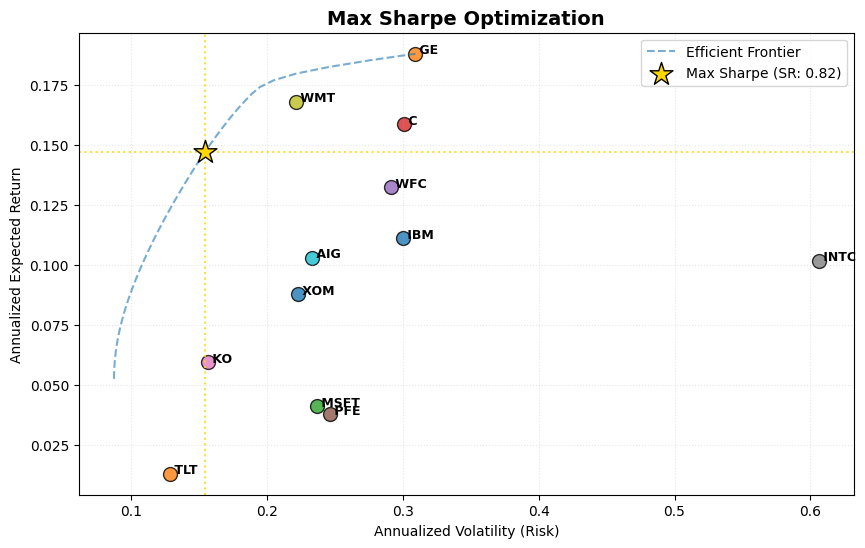

In [44]:
fig, weights = plot_efficient_frontier(bl_df, cv, basket, find_max_sharpe = True)
plt.show()


In [14]:
weights


XOM     1.609886e-01
GE      1.635203e-01
MSFT    4.390521e-17
C       5.895445e-02
WFC     1.296080e-02
PFE     0.000000e+00
KO      1.192770e-01
INTC    3.935632e-16
WMT     4.352694e-01
AIG     5.406602e-03
IBM     4.362285e-02
TLT     0.000000e+00
Name: Optimal weights, dtype: float64

In [15]:
price_data = get_full_portfolio_df(basket, start_date = start_date)




Fetching data for XOM...
Fetching data for GE...
Fetching data for MSFT...
Fetching data for C...
Fetching data for WFC...
Fetching data for PFE...
Fetching data for KO...
Fetching data for INTC...
Fetching data for WMT...
Fetching data for AIG...
Fetching data for IBM...
Fetching data for TLT...


In [47]:
cleaned_hrp


XOM     0.09847
GE      0.03858
MSFT    0.06853
C       0.02337
WFC     0.02477
PFE     0.05640
KO      0.14035
INTC    0.01342
WMT     0.08834
AIG     0.07126
IBM     0.05028
TLT     0.32624
dtype: float64

In [16]:
cleaned_hrp = run_hrp_optimization(price_data)
hrp_ret, hrp_vol, hrp_sharpe = get_returns(cleaned_hrp, price_data, stats, cv)
print(f"HRP Sharpe Ratio: {hrp_sharpe:.2f}")


HRP Sharpe Ratio: 0.84


In [17]:
cleaned_cvar = run_cvar_optimization(price_data)
cvar_ret, cvar_vol, cvar_sharpe = get_returns(cleaned_cvar, price_data, stats, cv)
print(f"CVAR Sharpe Ratio: {cvar_sharpe:.2f}\nCVAR Ret: {cvar_ret:.2f}\nCVAR Vol: {cvar_vol:.2f}")


CVAR Sharpe Ratio: 1.32
CVAR Ret: 0.15
CVAR Vol: 0.10


In [18]:
print(f"CVAR Sharpe Ratio: {cvar_sharpe:.2f}\nCVAR Ret: {cvar_ret:.2f}\nCVAR Vol: {cvar_vol:.2f}")
print(f"HRP Sharpe Ratio: {hrp_sharpe:.2f}\nHRP Ret: {hrp_ret:.2f}\nHRP Vol: {hrp_vol:.2f}")


CVAR Sharpe Ratio: 1.32
CVAR Ret: 0.15
CVAR Vol: 0.10
HRP Sharpe Ratio: 0.84
HRP Ret: 0.10
HRP Vol: 0.09


In [19]:
from helper import run_10yr_backtest, run_mpt_optimization, extract_portfolio_metrics, calculate_average_turnover


In [20]:
def run_spy_benchmark(price_data, start_idx=252):
    """
    Simulates a $100 investment in SPY starting from the 
    first rebalance date of the other models.
    """
    # 1. Isolate SPY returns
    spy_returns = price_data['SPY'].pct_change().dropna()
    
    # 2. Align the start date with your other backtests (after the 1yr lookback)
    spy_test_returns = spy_returns.iloc[start_idx:]
    
    # 3. Calculate the cumulative growth of $100
    spy_equity_curve = 100 * (1 + spy_test_returns).cumprod()
    
    return spy_equity_curve


In [48]:
price_data


,XOM,GE,MSFT,C,WFC,PFE,KO,INTC,WMT,AIG,IBM,TLT
Date,,,,,,,,,,,,
2024-01-02 05:00:00,102.36,100.5188,370.870,53.040,49.330,29.730,59.820,47.80,53.0967,68.840,161.500,98.310
2024-01-03 05:00:00,103.22,99.0104,370.600,53.640,48.680,29.730,59.960,47.05,53.1000,68.610,160.100,98.720
2024-01-04 05:00:00,102.32,99.4892,367.940,53.770,49.280,29.090,59.760,46.87,52.5867,68.630,160.860,97.220
2024-01-05 05:00:00,102.63,100.7901,367.750,54.330,49.920,29.470,59.670,46.89,52.2367,69.010,159.160,96.290
2024-01-08 05:00:00,100.92,102.3783,374.690,54.010,49.920,29.580,60.110,48.45,52.7500,68.220,161.140,97.240
...,...,...,...,...,...,...,...,...,...,...,...,...
2026-03-03 05:00:00,151.83,334.1400,403.930,110.760,82.530,26.580,79.340,43.10,127.9100,79.060,245.280,89.430
2026-03-04 05:00:00,149.82,339.8100,405.200,111.320,83.930,26.620,78.100,45.58,127.8100,78.300,250.060,89.150
2026-03-05 05:00:00,150.76,326.9900,410.680,108.950,82.110,26.610,77.030,45.95,123.3100,80.070,256.550,88.790


In [21]:
back_price_data = get_full_portfolio_df(basket, start_date = "2005-01-01")
mpt_sharpe_ec, mpt_sharpe_weights = run_10yr_backtest(back_price_data, lambda data: run_mpt_optimization(data, find_max_sharpe = True), rebalance_days = 30, lookback_days = 100)
mpt_vol_ec, mpt_vol_weights = run_10yr_backtest(back_price_data, lambda data: run_mpt_optimization(data, target_vol = 0.1), rebalance_days = 30, lookback_days = 100)
hrp_ec, hrp_weights = run_10yr_backtest(back_price_data, run_erp_optimization, rebalance_days = 30, lookback_days = 100)
cvar_ec, cvar_weights = run_10yr_backtest(back_price_data, run_nrp_optimization, rebalance_days = 30, lookback_days = 100)
spy_ec = run_spy_benchmark(get_full_portfolio_df(["SPY"], start_date = "2005-01-01"))


Fetching data for XOM...
Fetching data for GE...
Fetching data for MSFT...
Fetching data for C...
Fetching data for WFC...
Fetching data for PFE...
Fetching data for KO...
Fetching data for INTC...
Fetching data for WMT...
Fetching data for AIG...
Fetching data for IBM...
Fetching data for TLT...
Fetching data for SPY...


In [22]:
mpt_sharpe_ec


2005-05-27 04:00:00    100.196354
2005-05-31 04:00:00    100.198679
2005-06-01 04:00:00    101.257169
2005-06-02 04:00:00    101.805189
2005-06-03 04:00:00    100.978736
                          ...    
2024-11-06 05:00:00    347.609057
2024-11-07 05:00:00    348.439433
2024-11-08 05:00:00    350.951647
2024-11-11 05:00:00    350.048541
2024-11-12 05:00:00    349.247803
Length: 4736, dtype: float64

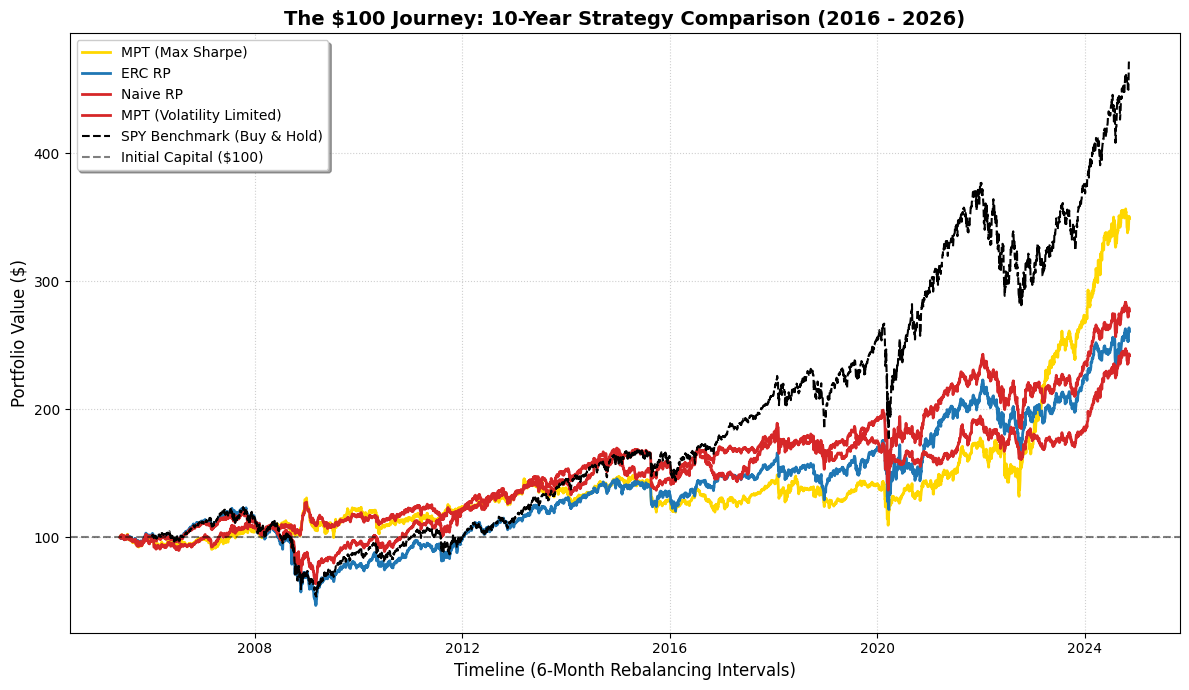

In [23]:
plt.figure(figsize=(12, 7))
    
plt.plot(mpt_sharpe_ec, label="MPT (Max Sharpe)", color='#FFD700', linewidth=2) # Gold
plt.plot(hrp_ec, label="ERC RP", color='#1f77b4', linewidth=2) # Blue
plt.plot(cvar_ec, label="Naive RP", color='#d62728', linewidth=2) # Red
plt.plot(mpt_vol_ec, label="MPT (Volatility Limited)", color='#d62728', linewidth=2) # Red

plt.plot(spy_ec, label="SPY Benchmark (Buy & Hold)", color='black', linestyle='--', linewidth=1.5)
plt.axhline(y=100, color='black', linestyle='--', alpha=0.5, label="Initial Capital ($100)")


plt.title("The $100 Journey: 10-Year Strategy Comparison (2016 - 2026)", fontsize=14, fontweight='bold')
plt.xlabel("Timeline (6-Month Rebalancing Intervals)", fontsize=12)
plt.ylabel("Portfolio Value ($)", fontsize=12)
plt.legend(loc='upper left', frameon=True, shadow=True)
plt.grid(True, linestyle=':', alpha=0.6)


plt.tight_layout()
plt.show()


In [24]:
extract_portfolio_metrics(mpt_sharpe_ec)


{'CAGR': '6.63%',
 'Volatility': '15.50%',
 'Sharpe Ratio': np.float64(0.3),
 'Max Drawdown': '-26.40%'}

In [25]:
extract_portfolio_metrics(mpt_vol_ec)


{'CAGR': '4.64%',
 'Volatility': '12.04%',
 'Sharpe Ratio': np.float64(0.22),
 'Max Drawdown': '-27.42%'}

In [26]:
extract_portfolio_metrics(hrp_ec)


{'CAGR': '5.05%',
 'Volatility': '19.05%',
 'Sharpe Ratio': np.float64(0.16),
 'Max Drawdown': '-61.97%'}

In [27]:
extract_portfolio_metrics(cvar_ec)


{'CAGR': '5.37%',
 'Volatility': '15.46%',
 'Sharpe Ratio': np.float64(0.22),
 'Max Drawdown': '-47.14%'}

In [28]:
extract_portfolio_metrics(spy_ec)


{'CAGR': '8.54%',
 'Volatility': '19.46%',
 'Sharpe Ratio': np.float64(0.34),
 'Max Drawdown': '-56.47%'}

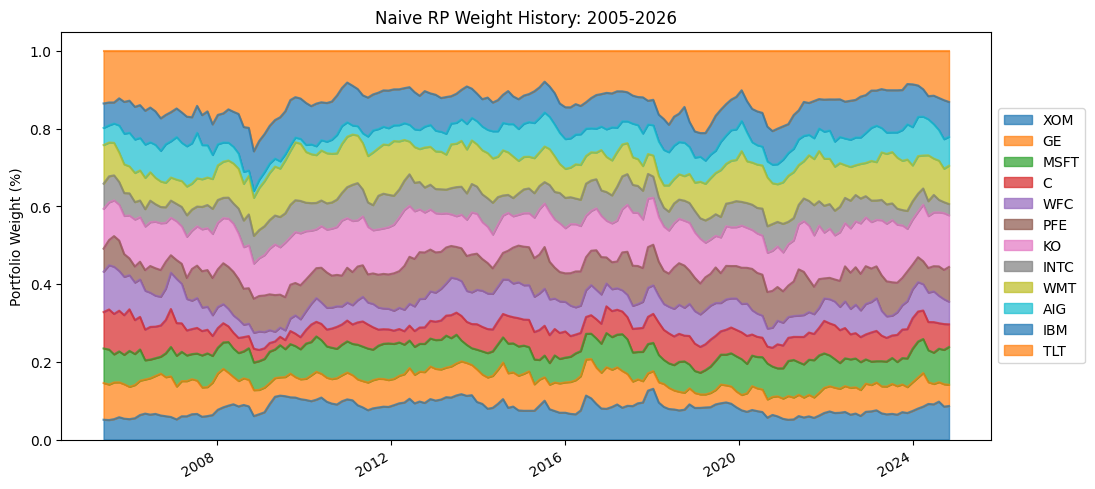

In [34]:
cvar_weights.plot(kind='area', stacked=True, alpha=0.7, figsize=(12, 6))
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.ylabel("Portfolio Weight (%)")
plt.title("Naive RP Weight History: 2005-2026")
plt.show()


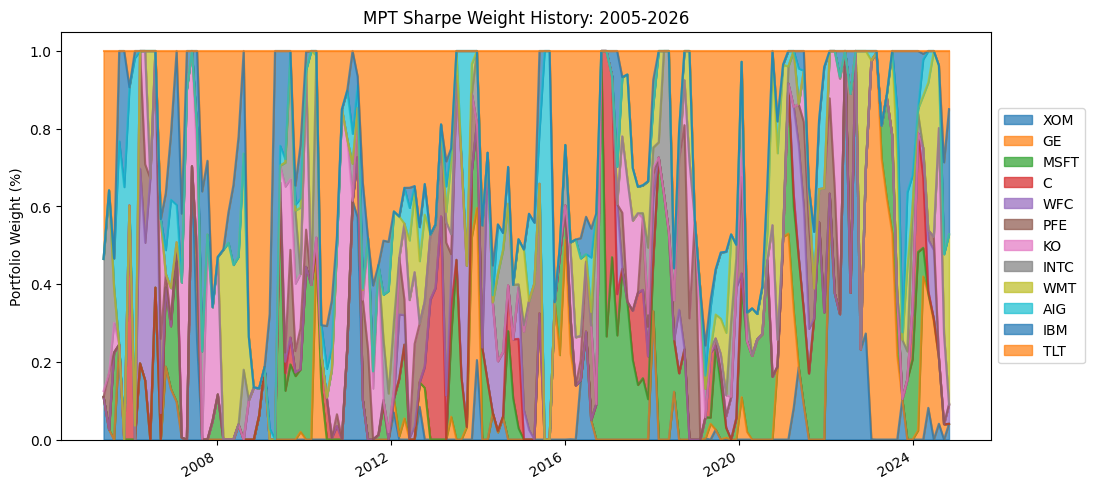

In [30]:
mpt_sharpe_weights.plot(kind='area', stacked=True, alpha=0.7, figsize=(12, 6))
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.ylabel("Portfolio Weight (%)")
plt.title("MPT Sharpe Weight History: 2005-2026")
plt.show()


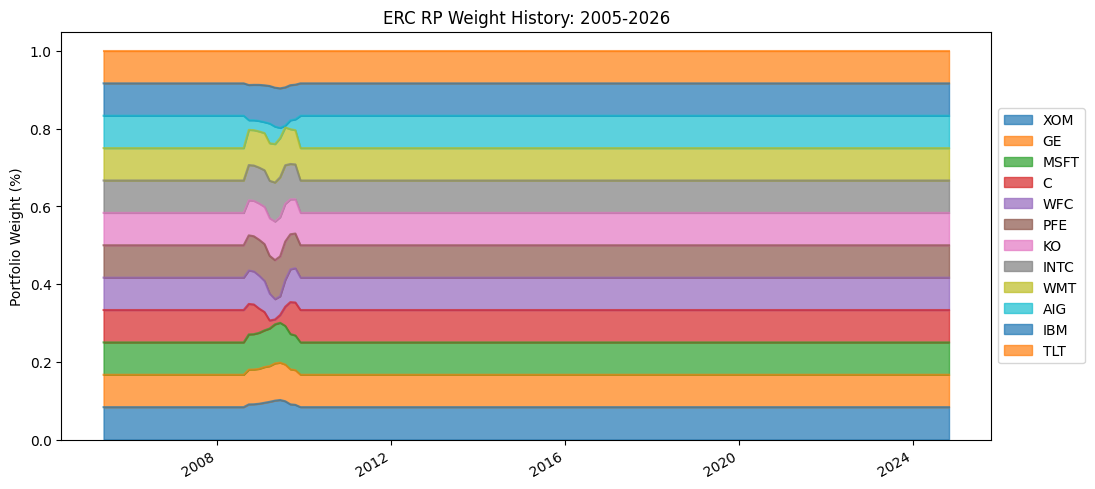

In [33]:
hrp_weights.plot(kind='area', stacked=True, alpha=0.7, figsize=(12, 6))
plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
plt.ylabel("Portfolio Weight (%)")
plt.title("ERC RP Weight History: 2005-2026")
plt.show()


In [32]:
# Example usage for your four strategies:
mpt_sharpe_turnover = calculate_average_turnover(mpt_sharpe_weights)
mpt_vol_turnover = calculate_average_turnover(mpt_vol_weights)
hrp_turnover = calculate_average_turnover(hrp_weights)
cvar_turnover = calculate_average_turnover(cvar_weights)

print(f"MPT Sharpe Average Turnover: {mpt_sharpe_turnover:.2%}")
print(f"MPT Vol Average Turnover: {mpt_vol_turnover:.2%}")
print(f"HRP Average Turnover: {hrp_turnover:.2%}")
print(f"CVaR Average Turnover: {cvar_turnover:.2%}")


MPT Sharpe Average Turnover: 43.63%
MPT Vol Average Turnover: 36.94%
HRP Average Turnover: 0.23%
CVaR Average Turnover: 3.78%
